# Notebook 04 — Event-centric LSTM evaluation: metrics, calibration, and interpretability

**Purpose:** this notebook evaluates the event-centric LSTM model (with Luong attention) and produces artefacts for the report:
- validation/test metrics (ROC-AUC, AP) and PR curve;
- **calibration** of probabilities (Isotonic/Temperature) with reliability/Brier;
- **interpretability** via attention on event-centric timelines;
- **Feature importance** post-hoc with **Occlusion ΔAP** (also for groups and subsets/cohorts).


> **Note for execution:** execute the cells in order. The functions provided here do not require model parameters as input: they use the previously loaded global `model` and the `DEVICE` set in the setup section.


In [1]:
# %% Setup
import os, json, glob, math, time, warnings
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    precision_recall_curve, roc_curve, roc_auc_score,
    average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve

plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=UserWarning)

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
RUN_ROOT = os.path.join("process_data", "processed_lstm")

# Risolvi OUT_RUN:
#  - If cell 01A has initialised OUT_RUN to an existing folder, use it.
#  - Otherwise, take the last available run_*.
if not ('OUT_RUN' in globals() and os.path.isdir(OUT_RUN)):
    runs = sorted([d for d in glob.glob(os.path.join(RUN_ROOT, "run_*")) if os.path.isdir(d)])
    assert runs, f"Nessun run_* in {RUN_ROOT}"
    OUT_RUN = runs[-1]

print("OUT_RUN:", OUT_RUN)

# Load config.json
with open(os.path.join(OUT_RUN, "config.json"), "r", encoding="utf-8") as f:
    cfg = json.load(f)

label_col       = cfg.get("label_col", "y_override")
features_input  = cfg.get("input_features", cfg.get("features_input", None))
all_features    = cfg.get("all_features_in_chunk", cfg.get("features", None))
center_idx      = int(cfg.get("center_idx", cfg.get("sequence_length_total", 48)//2))
SAVE_DIR        = cfg.get("save_dir_chunks", None)

print("label_col:", label_col)
print("features_input:", features_input)
print("center_idx:", center_idx)
print("SAVE_DIR:", SAVE_DIR)

# Split indices
idx_tr = np.load(os.path.join(OUT_RUN, "idx_train.npy"))
idx_v  = np.load(os.path.join(OUT_RUN, "idx_val.npy"))
idx_te = np.load(os.path.join(OUT_RUN, "idx_test.npy"))

# Array (scalati in 02)
X_tr = np.load(os.path.join(OUT_RUN, "X_train.npy")).astype(np.float32)
y_tr = np.load(os.path.join(OUT_RUN, "y_train.npy")).astype(np.int8)
X_v  = np.load(os.path.join(OUT_RUN, "X_val.npy")).astype(np.float32)
y_v  = np.load(os.path.join(OUT_RUN, "y_val.npy")).astype(np.int8)
X_te = np.load(os.path.join(OUT_RUN, "X_test.npy")).astype(np.float32)
y_te = np.load(os.path.join(OUT_RUN, "y_test.npy")).astype(np.int8)

T = X_tr.shape[1]
F = X_tr.shape[2]
print("Shapes →", "X_tr", X_tr.shape, "| X_v", X_v.shape, "| X_te", X_te.shape, "| F", F, "| T", T)

# utile per identificare l'indice dell'energia se presente
def safe_index(lst, name, default=0):
    try:
        return lst.index(name)
    except Exception:
        return default

energy_idx = safe_index(features_input or [], "energy_Wh", 0)
print("energy_idx:", energy_idx)

OUT_RUN: process_data/processed_lstm/run_20250826_1904
label_col: y_override
features_input: ['energy_Wh', 'reward_rate', 'notice_time', 'week_in_trial', 'hour_sin', 'hour_cos', 'temperature', 'wind_u', 'wind_v', 'precip_mm_log', 'ssrd_kwh', 'snr_kwh']
center_idx: 24
SAVE_DIR: process_data/event_sequences_chunks
Shapes → X_tr (185156, 25, 12) | X_v (35248, 25, 12) | X_te (35489, 25, 12) | F 12 | T 25
energy_idx: 0


In [2]:
# Riproducibilità base
def seed_everything(seed: int = 42):
    import random, os
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False  # True => lento; False ok per eval
    torch.backends.cudnn.benchmark = True

seed_everything(42)

# Helper per indicizzare meta safely
def take(a, idx):
    if a is None: return np.array([])
    if not isinstance(a, np.ndarray): a = np.asarray(a)
    if a.size == 0: return np.array([])
    if idx.max() >= a.shape[0]:
        return np.array([])
    return a[idx]

def sigmoid_stable(x):
    # evita overflow su exp
    x = np.clip(x, -50, 50, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-x))

def warn_if_few_levels(p, name="p"):
    nunique = np.unique(np.round(p, 6)).size
    if nunique < 50:
        print(f"[WARN] {name}: solo {nunique} livelli unici → curve “a gradini”. "
              f"Usa p_raw per PR/ROC e p_cal solo per reliability/Brier.")

In [3]:
from torch.utils.data import Dataset, DataLoader

class EventSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y.astype(np.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return {
            "x": torch.from_numpy(self.X[i]),
            "y": torch.tensor(self.y[i])
        }

def make_loader(X, y, batch_size=1024, shuffle=False):
    ds = EventSequenceDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=False)

In [4]:
# --- model definitions  -----------------
import math, torch
import torch.nn as nn

class DotAttention(nn.Module):
    """
    'add' (Bahdanau) or 'dot' (Luong). Name kept stable for backward-compatibility.
    """
    def __init__(self, d_h, kind="add"):
        super().__init__()
        self.kind = kind
        if kind == "add":
            self.W = nn.Linear(d_h, d_h, bias=False)
            self.v = nn.Linear(d_h, 1,   bias=False)

    def forward(self, H):                     # H: (B,T,h)
        if self.kind == "add":
            e = self.v(torch.tanh(self.W(H))).squeeze(-1)      # (B,T)
        else:  # "dot" using last hidden as query (Luong)
            q = H[:, -1, :].unsqueeze(-1)                      # (B,h,1)
            e = (H @ q).squeeze(-1) / math.sqrt(H.size(-1))    # (B,T)
        a = torch.softmax(e, dim=1)                            # (B,T)
        c = (a.unsqueeze(-1) * H).sum(1)                       # (B,h)
        return c, a

# Optional: feature gating over channels (lightweight channel-importance)
class FeatureGate(nn.Module):
    def __init__(self, in_dim, d_h=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, d_h), nn.Tanh(), nn.Linear(d_h, in_dim)
        )

    def forward(self, X):                      # X: (B,T,F)
        w = torch.softmax(self.net(X.mean(1)), dim=-1)         # (B,F)
        Xg = X * w.unsqueeze(1)                                # broadcast (B,T,F)
        return Xg, w

class LSTMMinimal(nn.Module):
    """
    Same name & API as before, but now supports:
      - attention_kind: 'add' or 'dot'
      - use_feature_gating: bool
      - num_layers, dropout (when num_layers>1)
    """
    def __init__(self, in_dim, hidden=128, num_layers=1, dropout=0.0,
                 use_attention=True, attention_kind="add",
                 use_feature_gating=False):
        super().__init__()
        self.use_attention     = bool(use_attention)
        self.attention_kind    = attention_kind
        self.use_feature_gating= bool(use_feature_gating)

        self.fgate = FeatureGate(in_dim) if self.use_feature_gating else None
        self.last_feat_w = None

        self.lstm = nn.LSTM(
            input_size=in_dim, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attn = DotAttention(hidden, kind=attention_kind) if self.use_attention else None
        self.fc   = nn.Linear(hidden, 1)

        # for plotting in 05
        self.last_attention = None

    def forward(self, x):                      # x: (B,T,F)
        if self.fgate is not None:
            x, w = self.fgate(x)
            self.last_feat_w = w

        H, _ = self.lstm(x)                    # (B,T,h)
        if self.attn is None:
            ctx = H[:, -1, :]                  # last state
            self.last_attention = None
        else:
            ctx, a = self.attn(H)              # attention pool
            self.last_attention = a

        z = self.fc(ctx)                       # (B,1)
        return z.squeeze(-1)

In [5]:
# build + load model exactly like in 04 
import os, json, torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

with open(os.path.join(OUT_RUN, "config.json"), "r", encoding="utf-8") as f:
    cfg = json.load(f)

# Backward-safe defaults in case the keys are missing
hidden              = int(cfg.get("hidden",            128))
num_layers          = int(cfg.get("num_layers",          1))
dropout             = float(cfg.get("dropout",         0.0))
use_attention       = bool(cfg.get("use_attention",    True))
attention_kind      = str(cfg.get("attention_kind",   "add"))   # 'add' or 'dot'
use_feature_gating  = bool(cfg.get("use_feature_gating", False))

in_dim = X_te.shape[2]   # F
model = LSTMMinimal(
    in_dim=in_dim, hidden=hidden,
    num_layers=num_layers, dropout=dropout,
    use_attention=use_attention, attention_kind=attention_kind,
    use_feature_gating=use_feature_gating
).to(DEVICE)

ckpt_path = os.path.join(OUT_RUN, "models", "lstm_minimal_1.pt")
state = torch.load(ckpt_path, map_location=DEVICE)
missing, unexpected = model.load_state_dict(state, strict=False)
print("[load_state_dict] missing:", missing, "| unexpected:", unexpected)
model.eval()

[load_state_dict] missing: ['attn.W.weight', 'attn.v.weight'] | unexpected: []


LSTMMinimal(
  (lstm): LSTM(12, 128, batch_first=True)
  (attn): DotAttention(
    (W): Linear(in_features=128, out_features=128, bias=False)
    (v): Linear(in_features=128, out_features=1, bias=False)
  )
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [6]:

def _ensure_numpy_1d(x):
    x = np.asarray(x)
    return x.reshape(-1)

try:
    sigmoid_stable
except NameError:
    def sigmoid_stable(x):
        """Stable sigmoid for 1-D/ND arrays.

        Avoid numeric overflow/underflow using two branches:
        - per x >= 0:   1 / (1 + exp(-x))
        - per x <  0:   exp(x) / (1 + exp(x))
        """
        x = np.asarray(x, dtype=np.float64)
        out = np.empty_like(x)
        pos = x >= 0
        neg = ~pos
        out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
        ex = np.exp(x[neg])
        out[neg] = ex / (1.0 + ex)
        return out

def predict_logits(X, batch_size=2048):
    """Restituisce i **logits 1‑D** per l'array 3‑D `X` usando il `model` globale.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (N, T, F) with event-centric sequences.
    batch_size : int, default=2048
        Batch size for the forward pass.

    Returns
    -------
    z : np.ndarray shape (N,)
        Logits del modello (pre‑sigmoid), uno per finestra.
    """
    assert X.ndim == 3, f"Atteso X con shape (N,T,F), ricevuto {X.shape}"
    model.eval()
    zs = []
    with torch.no_grad():
        for i in range(0, X.shape[0], batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(DEVICE).float()
            z  = model(xb)  # logits
            zs.append(z.detach().cpu().numpy())
    z = np.concatenate(zs, axis=0).astype(np.float64).reshape(-1)
    return z

def predict_proba_raw(X, batch_size=2048):
    """Returns the corresponding **raw 1-D probabilities** and **logits**.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (N, T, F) with the event-centric sequences.
    batch_size : int, default=2048

    Returns
    -------
    p : np.ndarray shape (N,)
        Raw probability (= sigmoid(logits)).
    z : np.ndarray shape (N,)
        Logits pre‑sigmoid.
    """
    z = predict_logits(X, batch_size=batch_size)
    p = sigmoid_stable(z)
    return p, z

# Alias for backward compatibility
model_predict_proba_raw = predict_proba_raw


VAL  — AP=0.167  ROC-AUC=0.711
TEST — AP=0.133 ROC-AUC=0.747


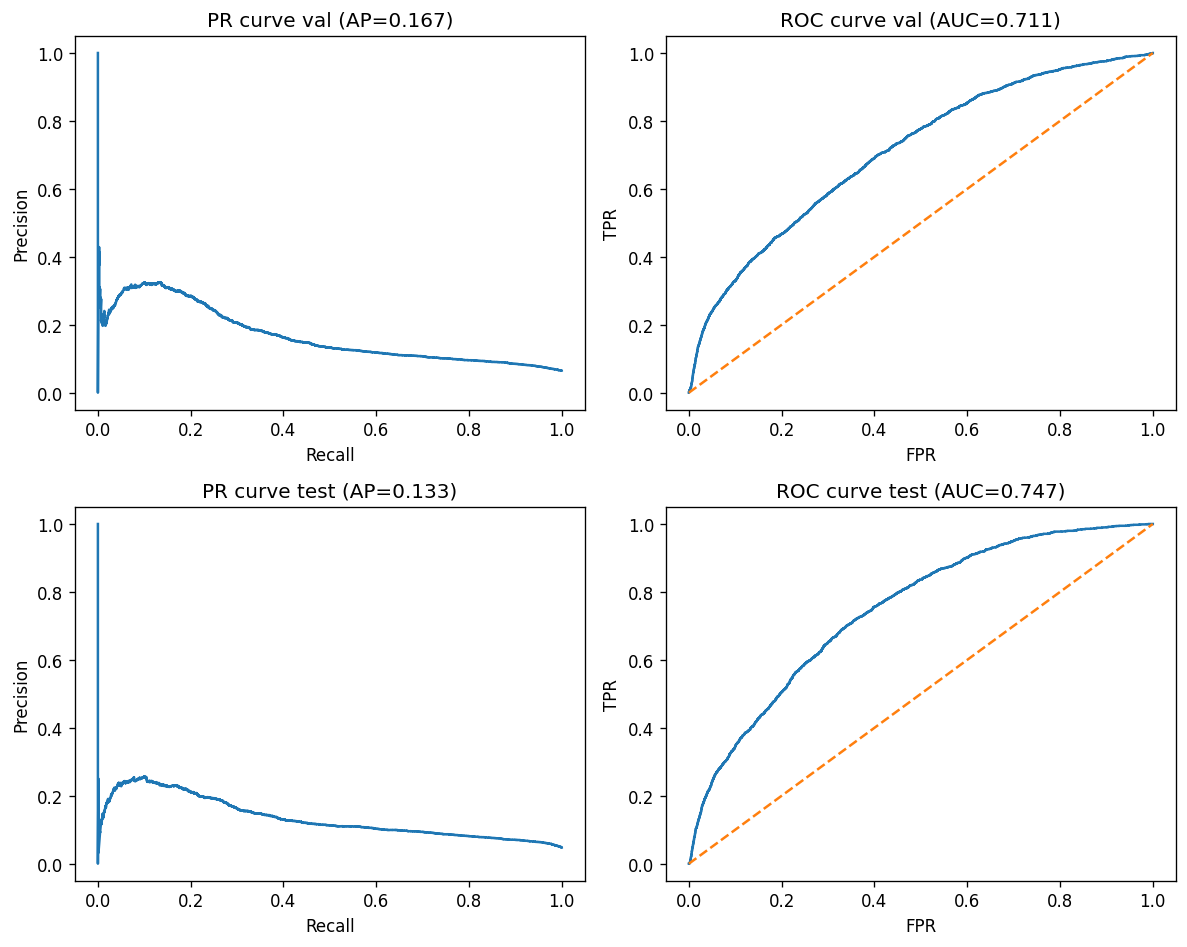

In [7]:
#Val
p_v_raw, z_v = predict_proba_raw(X_v)
warn_if_few_levels(p_v_raw, "p_v_raw")
pr_v, rc_v, _ = precision_recall_curve(y_v, p_v_raw)
ap_v = average_precision_score(y_v, p_v_raw)
fpr_v, tpr_v, _ = roc_curve(y_v, p_v_raw)
auc_v = roc_auc_score(y_v, p_v_raw)

# Test
p_te_raw, z_te = predict_proba_raw(X_te)
warn_if_few_levels(p_te_raw, "p_te_raw")
pr_te, rc_te, _ = precision_recall_curve(y_te, p_te_raw)
ap_te = average_precision_score(y_te, p_te_raw)
fpr_te, tpr_te, _ = roc_curve(y_te, p_te_raw)
auc_te = roc_auc_score(y_te, p_te_raw)

print(f"VAL  — AP={ap_v:.3f}  ROC-AUC={auc_v:.3f}")
print(f"TEST — AP={ap_te:.3f} ROC-AUC={auc_te:.3f}")

# Plot PR/ROC detailed (RAW)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0,0].plot(rc_v, pr_v); axs[0,0].set_title(f"PR curve val (AP={ap_v:.3f})"); axs[0,0].set_xlabel("Recall"); axs[0,0].set_ylabel("Precision")
axs[0,1].plot(fpr_v, tpr_v); axs[0,1].plot([0,1],[0,1],'--'); axs[0,1].set_title(f"ROC curve val (AUC={auc_v:.3f})"); axs[0,1].set_xlabel("FPR"); axs[0,1].set_ylabel("TPR")
axs[1,0].plot(rc_te, pr_te); axs[1,0].set_title(f"PR curve test (AP={ap_te:.3f})"); axs[1,0].set_xlabel("Recall"); axs[1,0].set_ylabel("Precision")
axs[1,1].plot(fpr_te, tpr_te); axs[1,1].plot([0,1],[0,1],'--'); axs[1,1].set_title(f"ROC curve test (AUC={auc_te:.3f})"); axs[1,1].set_xlabel("FPR"); axs[1,1].set_ylabel("TPR")
plt.tight_layout()
plt.show()

## Event-centric timeline + attention (Top-k)
The following function:
- **always** recomputes probabilities from the current model (default `recompute=True`);
- allows you to choose only **positive** examples (`pos_only=True`) so that the patterns shown are actual episodes of override;
- extracts **attention** weights directly from the last forward (`model.last_attention`);

In [8]:
def safe_index(seq, item, default=0):
    try:
        return list(seq).index(item)
    except ValueError:
        return default

@torch.no_grad()
def get_attention_for_examples(X_sel):
    """Returns the attention matrix for a sub-batch X_sel (shape: k, T, F).

    Requires that the model has been instantiated with `use_attention=True` and that
    exposes `last_attention` after the forward.
    """
    xb = torch.from_numpy(X_sel).to(DEVICE).float()
    _  = model(xb)                     # forward: popola model.last_attention
    a  = getattr(model, "last_attention", None)
    if a is None:
        return None
    return a.detach().cpu().numpy()

def plot_timeline_attention_topk(dataset='test', topk=3, save=True, pos_only=True, recompute=True):
    """Draw a panel with `topk` event-centric timelines and attention weights.

    Parameters
    ----------
    dataset : {“test”,'val'}, default=“test”
        Data source (use X_te/y_te or X_v/y_v).
    topk : int, default=3
        Number of examples to display.
    save : bool, default=True
        If True, saves PNG/PDF in `OUT_RUN`.
    pos_only : bool, default=True
        If True, selects only examples with y==1 (true positives).
    recompute : bool, default=True
        If True, recalculates p with the current model (avoids stale caches).

    Returns
    -------
    top_idx : np.ndarray shape (topk,)
        Indices chosen in the selected dataset.
    """
    if dataset == 'val':
        X, y = X_v, y_v
        cache_name = 'p_v_raw'
    else:
        X, y = X_te, y_te
        cache_name = 'p_te_raw'

    # 1) probabilità dal modello corrente (o cache se permesso)
    if recompute or cache_name not in globals():
        p, _ = predict_proba_raw(X)
        globals()[cache_name] = p
    else:
        p = globals()[cache_name]

    # 2) top-k
    if pos_only:
        mask = (y == 1)
        pool = np.where(mask)[0]
        if pool.size == 0:
            raise ValueError(f"No positive in the set '{dataset}'.")
        order = np.argsort(-p[mask])[:topk]
        top_idx = pool[order]
    else:
        top_idx = np.argsort(-p)[:topk]

    X_sel, y_sel, p_sel = X[top_idx], y[top_idx], p[top_idx]

    # 3) weights of attention
    a_sel = get_attention_for_examples(X_sel)
    if a_sel is None:
        raise RuntimeError("Attention is not active in the loaded model.")

    # 4) plot
    T = X_sel.shape[1]
    t_rel = np.arange(T) - int(center_idx)
    energy_idx = safe_index(features_input, "energy_Wh", 0)

    fig, axes = plt.subplots(topk, 1, figsize=(10, 2.8*topk), sharex=True)
    if topk == 1:
        axes = [axes]

    for r, ax in enumerate(axes):
        # energy scaled [0,1]
        e = X_sel[r, :, energy_idx]
        e = (e - e.min()) / (e.max() - e.min() + 1e-9)
        # attention normalized [0,1]
        att = a_sel[r, :]
        att = (att - att.min()) / (att.max() - att.min() + 1e-9)

        ax.bar(t_rel, att, width=1.0, alpha=0.35, label="attention (norm)")
        ax.plot(t_rel, e, linewidth=1.8, label="energy_Wh (scaled)")
        ax.axvline(0, linestyle='--', linewidth=1.0)
        ax.set_ylim(0.0, 1.05)
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)
        ax.set_ylabel('scaled')
        ax.set_title(f"sample {r+1} — p={float(p_sel[r]):.3f}  y={int(y_sel[r])}")
    axes[-1].set_xlabel("time slots relative to the event (t=0 at center)")
    fig.suptitle("Event‑centric timeline with attention — top‑3 (positives)")
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save:
        import os
        out_png = os.path.join(OUT_RUN, "fig_timeline_attention_top3.png")
        out_pdf = os.path.join(OUT_RUN, "fig_timeline_attention_top3.pdf")
        fig.savefig(out_png, bbox_inches="tight")
        fig.savefig(out_pdf, bbox_inches="tight")
        print("Figures saved in:", out_png, "e", out_pdf)

    return top_idx


Figures saved in: process_data/processed_lstm/run_20250826_1904/fig_timeline_attention_top3.png e process_data/processed_lstm/run_20250826_1904/fig_timeline_attention_top3.pdf


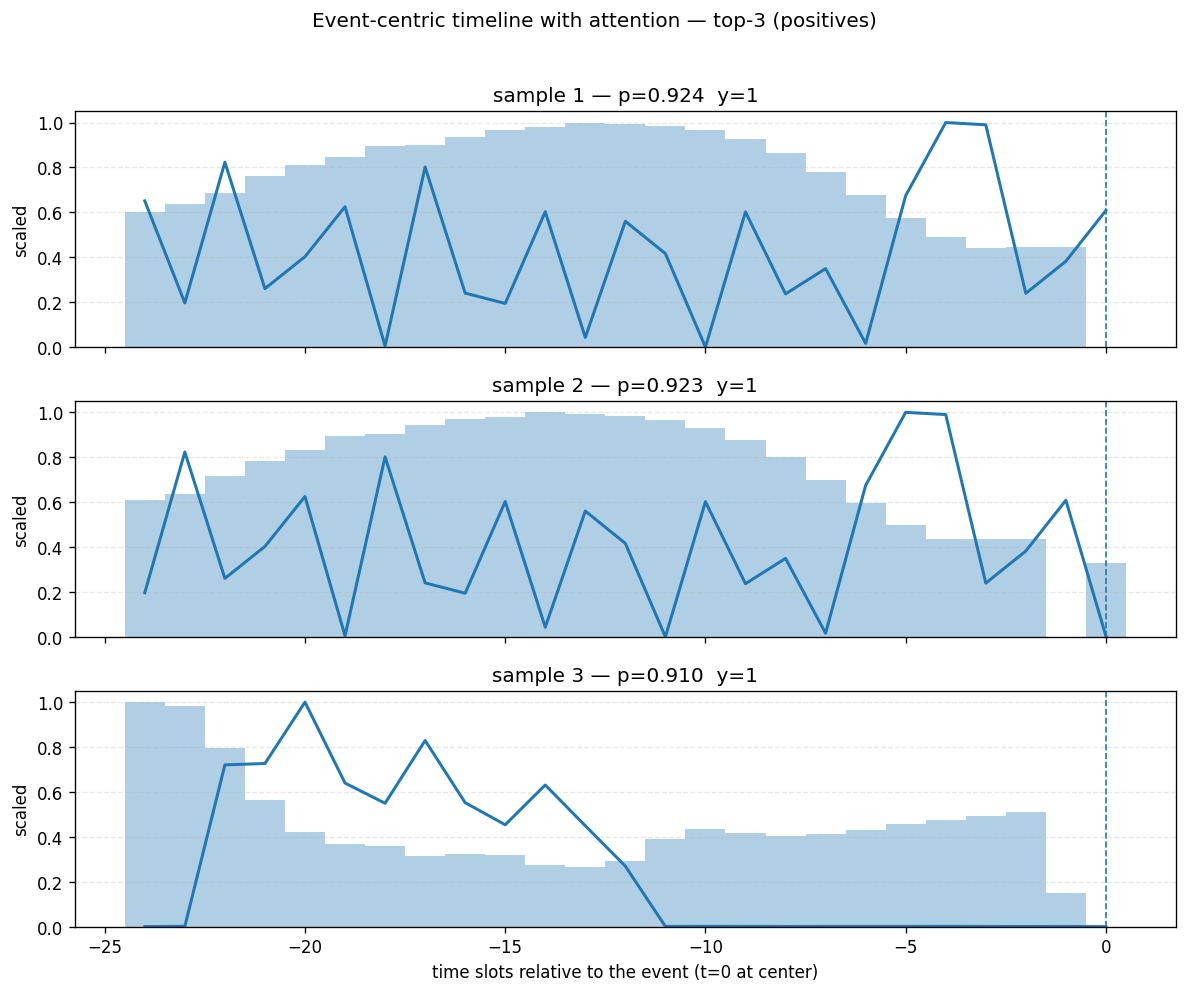

In [9]:
_ = plot_timeline_attention_topk(dataset='test', topk=3, pos_only=True, recompute=True, save=True)

[Isotonic] Brier(test) = 0.044


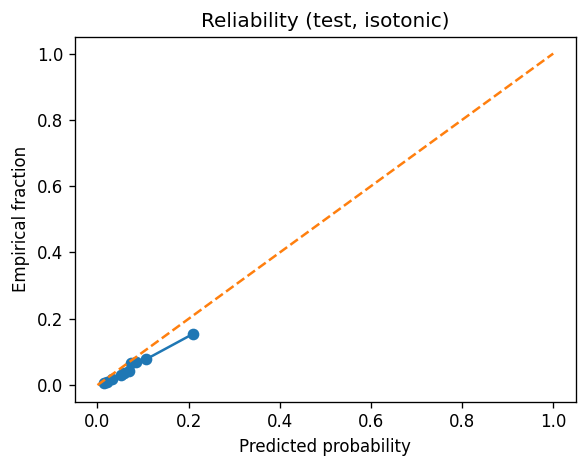

In [12]:
# --- Isotonic calibration (val -> test), for reliability/Brier only ---

def fit_isotonic(p_val_raw, y_val):
    eps = 1e-6
    p = np.clip(np.asarray(p_val_raw), eps, 1 - eps)
    ir = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
    ir.fit(p, np.asarray(y_val))
    return ir

# Fit on VAL, transform TEST
iso_cal = fit_isotonic(p_v_raw, y_v)
p_te_cal_iso = iso_cal.transform(np.clip(p_te_raw, 1e-6, 1-1e-6))

# Reliability / Brier with isotonic
rel_frac_iso, rel_prob_iso = calibration_curve(y_te, p_te_cal_iso, n_bins=10, strategy="quantile")
brier_iso = brier_score_loss(y_te, p_te_cal_iso)
print(f"[Isotonic] Brier(test) = {brier_iso:.3f}")

plt.figure(figsize=(5,4))
plt.plot(rel_prob_iso, rel_frac_iso, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Reliability (test, isotonic)")
plt.xlabel("Predicted probability"); plt.ylabel("Empirical fraction")
plt.tight_layout(); plt.show()

Temperature T*: 16.445
Brier (test, cal) = 0.251


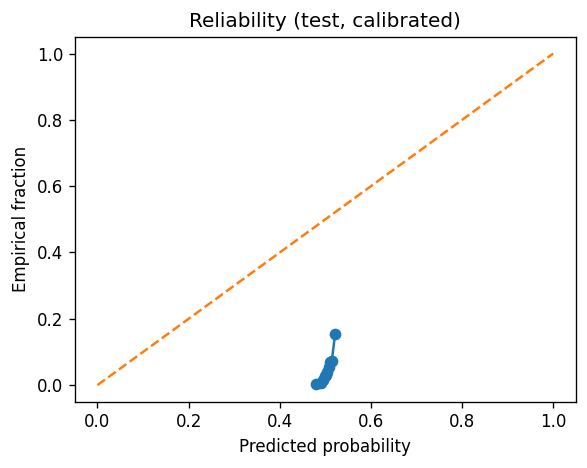

In [13]:
# Temperature scaling: adapt T on validation
def nll_T(T, z, y):
    p = sigmoid_stable(z / T)
    eps = 1e-9
    p = np.clip(p, eps, 1-eps)
    return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()

def fit_temperature(z, y):
    # Crude log-T scale search to avoid SciPy
    grid = np.exp(np.linspace(-2.5, 2.5, 61))  # T ∈ [e^-2.5, e^2.5]
    vals = [nll_T(T, z, y) for T in grid]
    T0 = grid[int(np.argmin(vals))]
    # micro-refine locale
    local = np.exp(np.linspace(np.log(T0)-0.3, np.log(T0)+0.3, 21))
    vals2 = [nll_T(T, z, y) for T in local]
    return float(local[int(np.argmin(vals2))])

T_opt = fit_temperature(z_v, y_v)
p_v_cal  = sigmoid_stable(z_v  / T_opt)
p_te_cal = sigmoid_stable(z_te / T_opt)

print(f"Temperature T*: {T_opt:.3f}")

# Reliability/Brier SOLO su p_cal
brier_te = brier_score_loss(y_te, p_te_cal)
rel_frac, rel_prob = calibration_curve(y_te, p_te_cal, n_bins=10, strategy='quantile')
print(f"Brier (test, cal) = {brier_te:.3f}")

# Plot reliability
plt.figure(figsize=(5,4))
plt.plot(rel_prob, rel_frac, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Reliability (test, calibrated)")
plt.xlabel("Predicted probability"); plt.ylabel("Empirical fraction")
plt.tight_layout(); plt.show()

## Occlusion ΔAP (single features or groups)

This implementation measures the **post-hoc importance** of each feature group as the
average loss of **Average Precision** relative to the reference (ΔAP = AP_ref − AP_occluded), using
two masking modes:
- `mask_mode=‘zero’`: resets the feature channels (hard occlusion);
- `mask_mode=‘shuffle’`: permutes the channels between windows, preserving marginal distributions (soft occlusion).


In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score

def occlusion_ap_groups(
    X, y, feature_names,
    groups=None,             # list of lists of feature names (None => singletons)
    mask_mode="shuffle",     # "shuffle" or "zero"
    subset_idx=None,         # optional indices to restrict analysis
    seeds=3, rnd=42,
    calibrator=None          # e.g., isotonic (callable or has .predict)
):
    """Occlusion ΔAP per feature groups on sequences (N,T,F).

    Parameters
    ----------
    X, y : np.ndarray
        Data and labels (X shape: (N,T,F)).
    feature_names : list[str]
        Names of F features in channel order.
    groups : list[list[str]] or None
        Groups of features to be occluded together. If None => individual features.
    mask_mode : {'shuffle','zero'}
        Occlusion strategy.
    subset_idx : np.ndarray or list or None
        Indexes (in the dataset) on which to calculate ΔAP. If None, use all.
    seeds : int
        Number of repetitions (only for 'shuffle').
    rnd : int
        initial seed for the RandomState.
    calibrator : callable or object with .predict or None
        If provided, applied to probabilities before calculating AP.

    Returns
    -------
    results : list[tuple[str, float]]
        List sorted by descending ΔAP: (group_name, average_ΔAP).
    """
    assert X.ndim == 3, f"Atteso X con shape (N,T,F), ricevuto {X.shape}"
    N, T, F = X.shape

    if subset_idx is not None:
        X_sub = X[subset_idx]
        y_sub = y[subset_idx]
    else:
        X_sub, y_sub = X, y

    # AP di riferimento
    p_ref, _ = predict_proba_raw(X_sub)
    if calibrator is not None:
        if hasattr(calibrator, "predict"):
            p_ref = calibrator.predict(p_ref)
        else:
            p_ref = calibrator(p_ref)
    ap_ref = average_precision_score(y_sub, p_ref)

    # Gruppi: single features if None
    if groups is None:
        groups = [[f] for f in feature_names]

    name_to_idx = {n: i for i, n in enumerate(feature_names)}
    rng = np.random.RandomState(rnd)

    results = []
    for group in groups:
        feat_idx = [name_to_idx[n] for n in group]
        deltas = []

        reps = seeds if mask_mode == "shuffle" else 1
        for rep in range(reps):
            X_occ = X_sub.copy()
            if mask_mode == "zero":
                X_occ[:, :, feat_idx] = 0.0
            elif mask_mode == "shuffle":
                # Let's permute the windows (axis 0) for the group channels.
                perm = rng.permutation(X_occ.shape[0])
                #X_occ[:, :, feat_idx] = X_occ[perm, :, feat_idx]
                X_occ[:, :, feat_idx] = np.take(np.take(X_occ, perm, axis=0), feat_idx, axis=2)

            else:
                raise ValueError("mask_mode deve essere 'shuffle' o 'zero'")

            p_occ, _ = predict_proba_raw(X_occ)
            if calibrator is not None:
                if hasattr(calibrator, "predict"):
                    p_occ = calibrator.predict(p_occ)
                else:
                    p_occ = calibrator(p_occ)
            ap_occ = average_precision_score(y_sub, p_occ)
            deltas.append(ap_ref - ap_occ)

        results.append(("+".join(group), float(np.mean(deltas))))

    # ordina per ΔAP decrescente
    results.sort(key=lambda x: x[1], reverse=True)
    return results


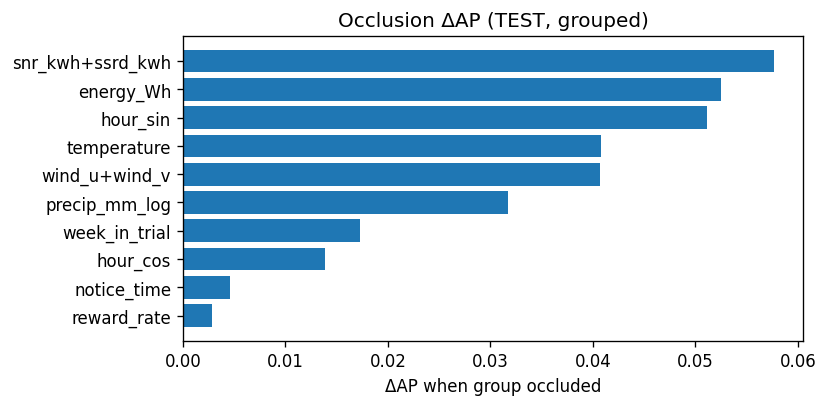

In [25]:
# group irradiance surfaces and winds; others as singletons
grouped = [
    ["snr_kwh", "ssrd_kwh"],
    ["wind_u", "wind_v"],
]
singletons = [[f] for f in features_input if f not in {"snr_kwh","ssrd_kwh","wind_u","wind_v"}]
groups = grouped + singletons

occ = occlusion_ap_groups(
    X_te, y_te, features_input,
    groups=groups, mask_mode="shuffle",
    seeds=3, rnd=42, calibrator=None
)

# plot (top 12 for readability)
names  = [n for n,_ in occ[:12]]
values = [v for _,v in occ[:12]]
plt.figure(figsize=(7, max(3, 0.35*len(names))))
plt.barh(names[::-1], values[::-1])
plt.title("Occlusion ΔAP (TEST, grouped)")
plt.xlabel("ΔAP when group occluded")
plt.tight_layout(); plt.show()

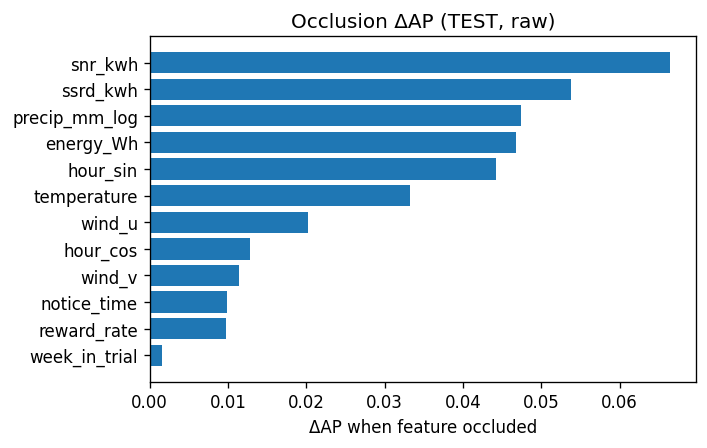

In [26]:
def occlusion_ap(X, y, features, mask_mode="shuffle", subset_idx=None, calibrator=None, rnd=42):
    """
    Returns a list [(feature_name, ΔAP)] sorted by importance.
    ΔAP = AP_full - AP_with_feature_occluded  (positive => useful feature)
    - mask_mode: “shuffle” | “zero” | “mean”
    - subset_idx: np.array of indices to use (e.g. for appliance/city)
    - calibrator: function p_raw -> p (if you want to apply calibration; for AP ranking, keep None)
    """
    rng = np.random.default_rng(rnd)

    X_ = X if subset_idx is None else X[subset_idx]
    y_ = y if subset_idx is None else y[subset_idx]

    # baseline AP su p_raw
    p_full, _ = model_predict_proba_raw(X_)
    if calibrator is not None:
        p_full = calibrator(p_full)
    ap_full = average_precision_score(y_, p_full)

    deltas = []
    for j, name in enumerate(features):
        Xm = X_.copy()
        if mask_mode == "shuffle":
            flat = Xm[:,:,j].reshape(-1)
            rng.shuffle(flat)
            Xm[:,:,j] = flat.reshape(Xm[:,:,j].shape)
        elif mask_mode == "zero":
            Xm[:,:,j] = 0.0
        elif mask_mode == "mean":
            Xm[:,:,j] = X[:,:,j].mean()
        else:
            raise ValueError("mask_mode must be 'shuffle'|'zero'|'mean'")

        p_m, _ = model_predict_proba_raw(Xm)
        if calibrator is not None:
            p_m = calibrator(p_m)
        ap_m = average_precision_score(y_, p_m)
        deltas.append((name, float(ap_full - ap_m)))

    return sorted(deltas, key=lambda t: t[1], reverse=True)

# --- Execution on TEST (RAW)
occ = occlusion_ap(X_te, y_te, features_input, mask_mode="shuffle", subset_idx=None, calibrator=None, rnd=42)

# Horizontal plot
names = [n for n,_ in occ]; vals = [v for _,v in occ]
plt.figure(figsize=(6, max(3, 0.32*len(names))))
plt.barh(names[::-1], vals[::-1])
plt.title("Occlusion ΔAP (TEST, raw)")
plt.xlabel("ΔAP when feature occluded")
plt.tight_layout()
plt.show()

In [13]:
def load_meta_concat(save_dir):
    # Search for meta_chunk_*.npz in SAVE_DIR (chunks folder from 01)
    files = sorted(glob.glob(os.path.join(save_dir, "**", "meta_chunk_*.npz"), recursive=True))
    if not files:
        print(f"[WARN] Nessun meta_chunk in {save_dir}")
        return {}
    merged = {}
    for f in files:
        d = np.load(f, allow_pickle=True)
        for k in d.files:
            merged.setdefault(k, []).append(d[k])
    for k in list(merged.keys()):
        try:
            merged[k] = np.concatenate(merged[k], axis=0)
        except Exception:
            # se tipi misti o lunghezze diverse, lascia lista
            pass
    return merged

meta_all = load_meta_concat(SAVE_DIR)

def build_df(y, p_raw, p_cal, idx, meta):
    return {
        "y": y.astype(int),
        "p_raw": p_raw.astype(float),
        "p_cal": p_cal.astype(float),
        "user": take(meta.get("user_ids", None), idx),
        "event_time": take(meta.get("event_times", None), idx),
        "actual_event": take(meta.get("actual_event", None), idx),
        "reward": take(meta.get("reward", None), idx),
        "appliance": take(meta.get("appliance", None), idx).astype(str) if "appliance" in meta else "",
        "city": take(meta.get("city", None), idx).astype(str) if "city" in meta else "",
    }

import pandas as pd
df_val  = pd.DataFrame(build_df(y_v,  p_v_raw,  p_v_cal,  idx_v,  meta_all))
df_test = pd.DataFrame(build_df(y_te, p_te_raw, p_te_cal, idx_te, meta_all))

# save
df_val.to_csv(os.path.join(OUT_RUN, "df_val_posthoc.csv"), index=False)
df_test.to_csv(os.path.join(OUT_RUN, "df_test_posthoc.csv"), index=False)

df_val.head(), df_test.head()

(   y     p_raw     p_cal         user          event_time actual_event reward  \
 0  0  0.397372  0.493670  60000288880 2024-02-07 15:00:00            0    0.0   
 1  0  0.367951  0.491776  60000288880 2024-02-07 15:30:00            0    0.0   
 2  0  0.353597  0.490830  60000288880 2024-02-07 17:00:00            0    0.0   
 3  0  0.341128  0.489994  60000288880 2024-02-07 17:30:00            0    0.0   
 4  0  0.379083  0.492499  60000288880 2024-02-10 14:00:00            0    0.0   
 
       appliance   city  
 0  Light / Bulb  Delhi  
 1  Light / Bulb  Delhi  
 2  Light / Bulb  Delhi  
 3  Light / Bulb  Delhi  
 4  Light / Bulb  Delhi  ,
    y     p_raw     p_cal         user          event_time actual_event reward  \
 0  0  0.323227  0.488767  60000335624 2024-01-15 21:00:00            0    0.0   
 1  0  0.261888  0.484253  60000335624 2024-01-15 21:30:00            0    0.0   
 2  0  0.300297  0.487143  60000335624 2024-01-16 19:00:00            0    0.0   
 3  0  0.296285  0.48

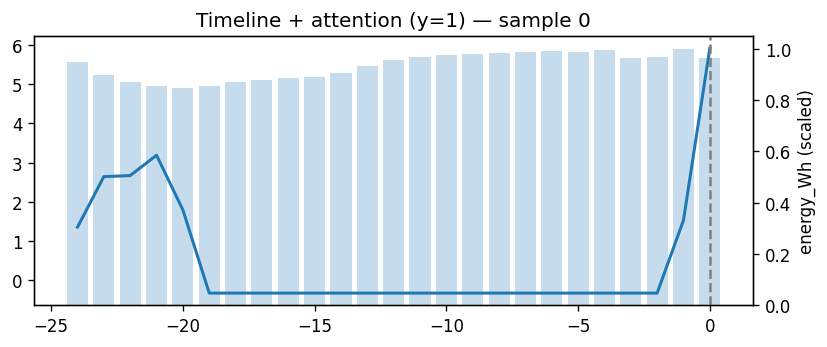

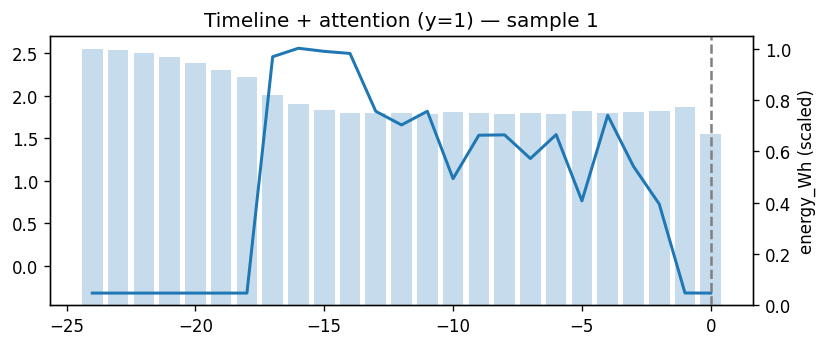

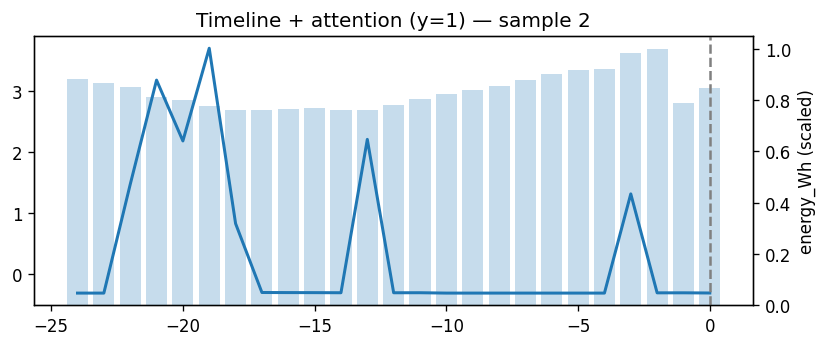

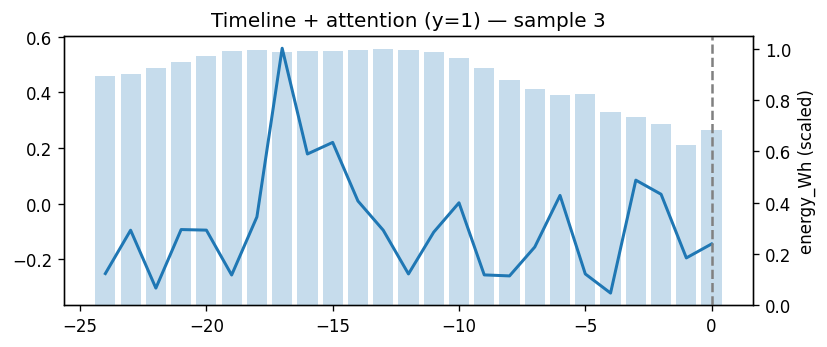

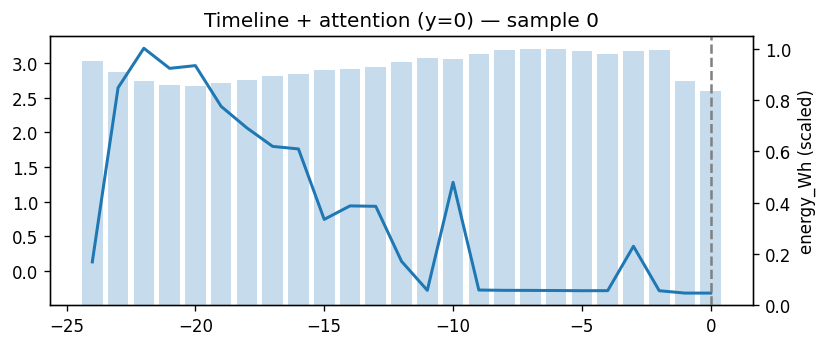

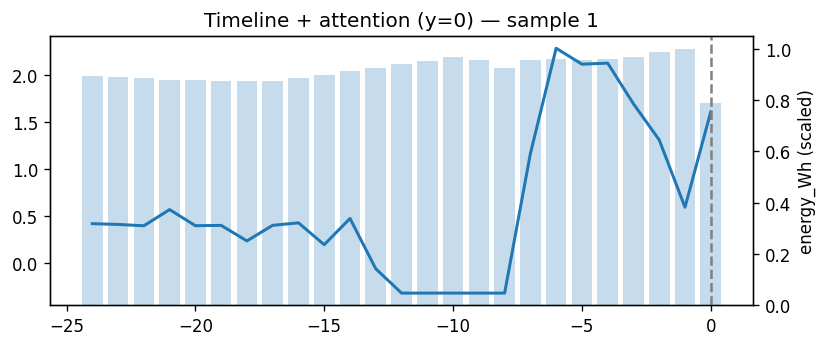

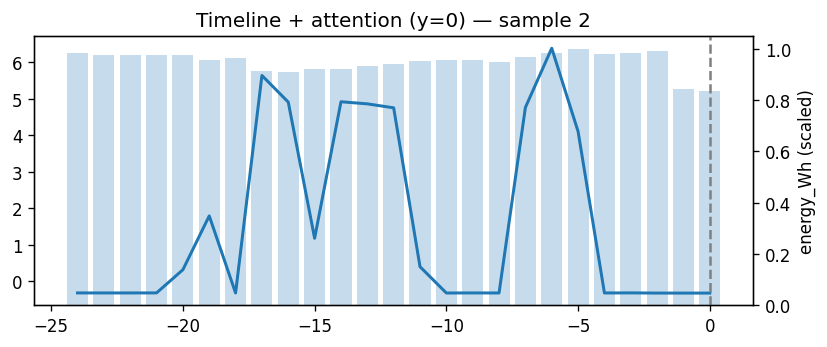

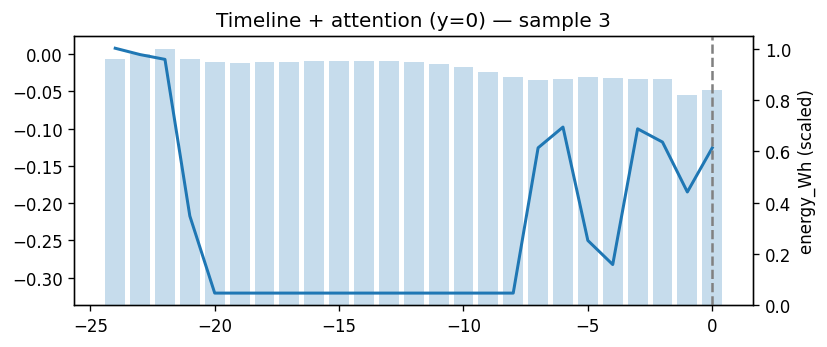

In [15]:
@torch.no_grad()
def get_attention_for_examples(X_sel):
    xb = torch.from_numpy(X_sel).to(DEVICE).float()
    _ = model(xb)  # forward per popolare last_attention
    a = model.last_attention
    if a is None:
        return None
    return a.detach().cpu().numpy()

def pick_examples_with_signal(X, y, k=4, center_idx=24, energy_idx=0):
    rng = np.random.default_rng(42)
    # media energia nei 3 step pre‑evento
    pre_mean = X[:, max(0,center_idx-3):center_idx, energy_idx].mean(axis=1)
    thr = np.nanquantile(pre_mean, 0.60)
    cand = np.where(pre_mean > thr)[0]
    if cand.size == 0: cand = np.arange(X.shape[0])
    if cand.size > k:  cand = rng.choice(cand, size=k, replace=False)
    return cand

def plot_timeline_with_attention(X, y, a, title_prefix, energy_idx=0, center_idx=24):
    # X: [k,T,F], a: [k,T] o None
    k, T, _ = X.shape
    t = np.arange(-center_idx, T-center_idx)
    for i in range(k):
        plt.figure(figsize=(7,3))
        plt.plot(t, X[i,:,energy_idx], lw=1.8)
        if a is not None:
            att = a[i] / (a[i].max() + 1e-9)
            plt.twinx()
            plt.bar(t, att, alpha=0.25)
            plt.ylabel("attention (norm.)")
        plt.axvline(0, ls="--", color="gray")
        plt.title(f"{title_prefix} — sample {i}")
        plt.xlabel("Δt (slots vs event)"); plt.ylabel("energy_Wh (scaled)")
        plt.tight_layout(); plt.show()

# Esempi y=1 e y=0
sel_pos = pick_examples_with_signal(X_te[y_te==1], y_te[y_te==1], k=4, center_idx=center_idx, energy_idx=energy_idx)
sel_neg = pick_examples_with_signal(X_te[y_te==0], y_te[y_te==0], k=4, center_idx=center_idx, energy_idx=energy_idx)

X_pos = X_te[y_te==1][sel_pos]
X_neg = X_te[y_te==0][sel_neg]

a_pos = get_attention_for_examples(X_pos)
a_neg = get_attention_for_examples(X_neg)

plot_timeline_with_attention(X_pos, y_te[y_te==1][sel_pos], a_pos, "Timeline + attention (y=1)",
                             energy_idx=energy_idx, center_idx=center_idx)
plot_timeline_with_attention(X_neg, y_te[y_te==0][sel_neg], a_neg, "Timeline + attention (y=0)",
                             energy_idx=energy_idx, center_idx=center_idx)

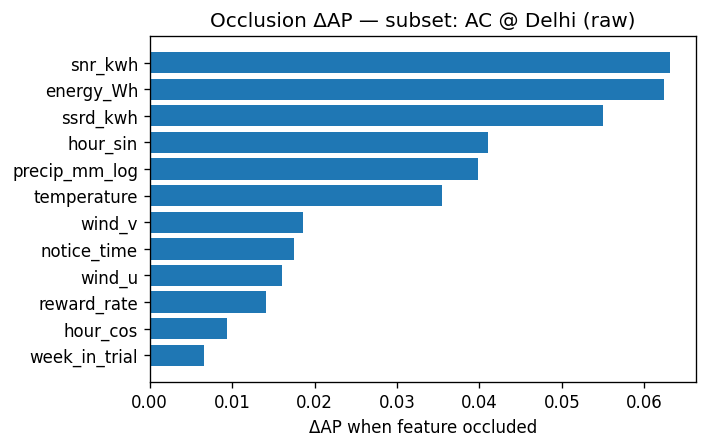

In [47]:
# Example subset (if metadata is available and aligned):
subset = None
if "appliance" in meta_all and "city" in meta_all:
    app = take(meta_all.get("appliance"), idx_te).astype(str)
    cty = take(meta_all.get("city"), idx_te).astype(str)
    subset = np.where((app=="AC") & (cty=="Delhi"))[0]
    if subset.size:
        occ_ac_delhi = occlusion_ap(X_te, y_te, features_input, mask_mode="shuffle", subset_idx=subset, calibrator=None, rnd=42)
        names = [n for n,_ in occ_ac_delhi]; vals = [v for _,v in occ_ac_delhi]
        plt.figure(figsize=(6, max(3, 0.32*len(names))))
        plt.barh(names[::-1], vals[::-1]); plt.title("Occlusion ΔAP — subset: AC @ Delhi (raw)")
        plt.xlabel("ΔAP when feature occluded"); plt.tight_layout(); plt.show()
    else:
        print("[INFO] Subset AC@Delhi empty.")
else:
    print("[INFO] Meta does not contain appliance/city → skip subset.")

In [33]:
# --- C4. Feature-gate weights summary  ---
import os, numpy as np, matplotlib.pyplot as plt

gate_candidates = [
    "feat_w_val_sample.npy",    # come salvato in 04 (val sample)
    "feat_w.npy",               # eventuale full
]
W = None
for fn in gate_candidates:
    path = os.path.join(OUT_RUN, fn)
    if os.path.exists(path):
        W = np.load(path)
        print("[INFO] loaded gate weights:", path, "| shape:", W.shape)
        break

if W is None:
    print("[INFO] No feature-gate weights found in", OUT_RUN)
else:
    W = np.asarray(W)
    if   W.ndim == 3:      # (k, T, F)
        w_mean = W.mean(axis=(0,1))
    elif W.ndim == 2:      # (k, F)
        w_mean = W.mean(axis=0)
    elif W.ndim == 1:      # (F,)
        w_mean = W
    else:
        raise ValueError(f"Unexpected gate weights shape: {W.shape}")

    order = np.argsort(w_mean)
    plt.figure(figsize=(6, 0.4*len(features_input)))
    plt.barh(np.array(features_input)[order], w_mean[order])
    plt.title("Feature‑gate average weights (val sample)")
    plt.xlabel("mean weight")
    plt.tight_layout(); plt.show()

[INFO] No feature-gate weights found in process_data/processed_lstm/run_20250826_1904


In [16]:
# # Robust event flag recovery
# ae = meta_all.get("actual_event")
# if ae is None:
#     ae = meta_all.get("actual_event_flag")
# # Recupero robusto del reward guadagnato e del reward_rate (se vuoi usarlo in plot)
# rew = meta_all.get("reward")
# rew_rate = meta_all.get("reward_rate")

In [63]:
print("share actual_event=1 (val/test):",
      np.mean(take(ae, idx_v)==1), np.mean(take(ae, idx_te)==1))
print("share reward>0 (solo actual_event=1, val/test):",
      np.mean(take(rew, idx_v)[take(ae, idx_v)==1] > 0),
      np.mean(take(rew, idx_te)[take(ae, idx_te)==1] > 0))

share actual_event=1 (val/test): 0.19606786200635498 0.1771816619234129
share reward>0 (solo actual_event=1, val/test): 0.6664737375198958 0.7307569974554707
